# Day 1 — Unsupervised Learning & K-Means

## Objective

The objective of this lab is to understand unsupervised learning and apply K-Means clustering to discover natural groups within a dataset.

In this lab, we will:

* Understand the difference between supervised and unsupervised learning.
* Explore the Mall Customers dataset.
* Select and scale numerical features.
* Use the Elbow Method to find suitable values of k.
* Use the Silhouette Score to compare candidate values of k.
* Train a final K-Means clustering model.
* Visualize and interpret the resulting customer clusters.


##  Load and Understand the Dataset

The Mall Customers dataset contains information about 200 customers. It includes customer ID, gender, age, annual income, and spending score.

The dataset will first be loaded and inspected to understand its structure, data types, and basic statistics.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
df.shape

(200, 5)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


##  Feature Selection

Since K-Means clustering is based on distance calculations, numerical features are used for clustering.

The CustomerID column is excluded because it is only an identifier and does not contain meaningful information about customer similarity. The Gender column is also excluded.
The selected features are:

* Age
* Annual Income (k$)
* Spending Score (1-100)


In [5]:
X = df.drop(["CustomerID","Gender"], axis =1)

##  Feature Scaling

K-Means uses distance calculations to assign observations to clusters. Therefore, features with larger numerical ranges could have a greater influence on the clustering process.

To prevent this problem, StandardScaler is used to standardize the selected features so that they are on a comparable scale.


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

##  Elbow Method

K-Means requires the number of clusters, k, to be specified before training.

The Elbow Method is used to evaluate different values of k. K-Means is trained for values from 1 to 10, and the inertia is recorded for each value.

Inertia measures the total within-cluster squared distance between data points and their assigned cluster centroids. It decreases as the number of clusters increases, so we look for the point where the decrease becomes less significant. This point is known as the **elbow**.


In [8]:
from sklearn.cluster import KMeans

inertias = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    km.fit(X_scaled)
    inertias.append(km.inertia_)

In [9]:
for k, inertia in zip(range(1, 11), inertias):
    print(f"k={k}: Inertia={inertia:.2f}")

k=1: Inertia=600.00
k=2: Inertia=389.39
k=3: Inertia=295.21
k=4: Inertia=205.23
k=5: Inertia=168.25
k=6: Inertia=133.87
k=7: Inertia=117.01
k=8: Inertia=103.87
k=9: Inertia=93.09
k=10: Inertia=82.39


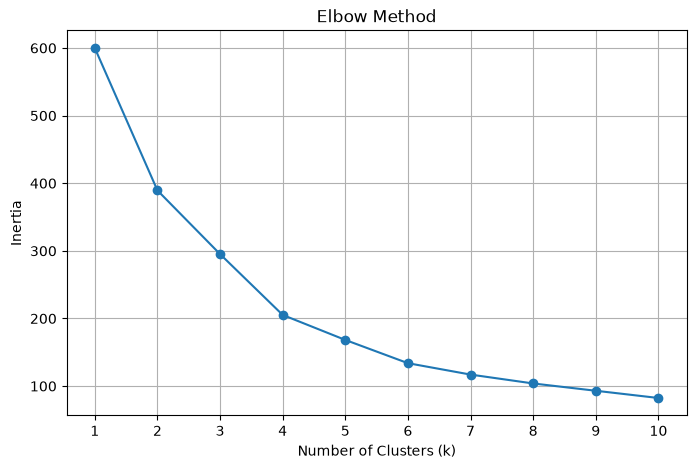

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), inertias, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

##  Silhouette Score

The Silhouette Score provides an additional quantitative measure of clustering quality.

It ranges from -1 to +1, where higher values generally indicate better-separated and more clearly defined clusters.

Based on the Elbow Method, k=3 and k=4 were selected as the two main candidate values. 

In [12]:
final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

In [14]:
df["Cluster"] = cluster_labels
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2
5,6,Female,22,17,76,2
6,7,Female,35,18,6,0
7,8,Female,23,18,94,2
8,9,Male,64,19,3,0
9,10,Female,30,19,72,2


In [20]:
df["Cluster"].value_counts().sort_index()

Cluster
0    65
1    40
2    57
3    38
Name: count, dtype: int64

In [21]:
features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

cluster_summary = df.groupby("Cluster")[features].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,53.984615,47.707692,39.969231
1,32.875000,86.100000,81.525000
2,25.438596,40.000000,60.298246
3,39.368421,86.500000,19.578947


## 9Cluster Interpretation

The K-Means algorithm identified four distinct customer segments based on age, annual income, and spending score.

* **Cluster 0:** Older customers with moderate income and moderate spending.
* **Cluster 1:** Relatively young customers with high income and high spending. This represents a high-value customer segment.
* **Cluster 2:** Young customers with relatively low income but moderate-to-high spending.
* **Cluster 3:** Customers with high income but low spending.

These clusters demonstrate that customers with similar income levels can have very different spending behaviors. In particular, Cluster 1 and Cluster 3 have similar high average incomes but significantly different spending scores.


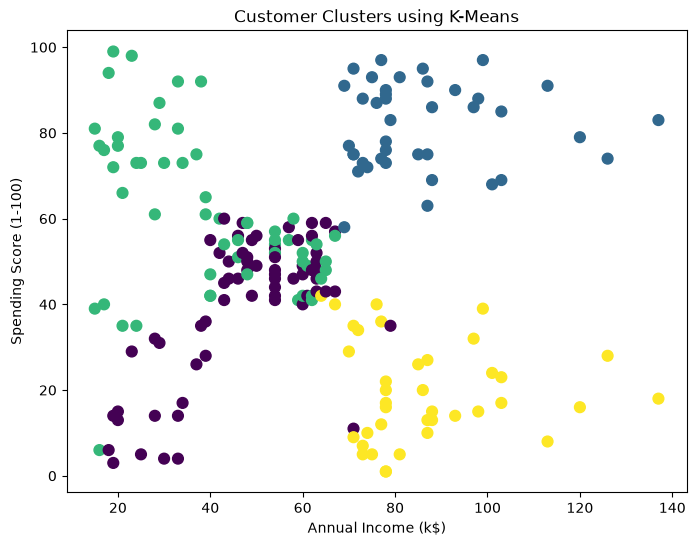

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=60
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Clusters using K-Means")

plt.show()

##  Cluster Visualization

The resulting clusters are visualized using a two-dimensional scatter plot.

Annual Income is represented on the x-axis, while Spending Score is represented on the y-axis. The cluster assignments are used to distinguish the different customer groups, and the final cluster centroids are also displayed.


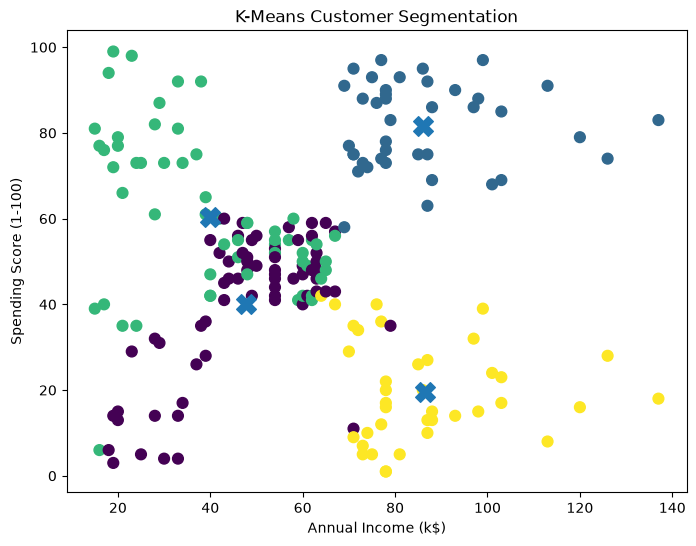

In [23]:
centroids_original = scaler.inverse_transform(
    final_kmeans.cluster_centers_
)

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=60
)

plt.scatter(
    centroids_original[:, 1],
    centroids_original[:, 2],
    marker="X",
    s=200
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Customer Segmentation")

plt.show()

##  Conclusion

In this lab, K-Means clustering was applied to the Mall Customers dataset to discover natural customer segments without using predefined labels.

The numerical features were standardized using StandardScaler to ensure that differences in feature scales did not dominate the distance calculations. The Elbow Method was then used to identify suitable values of k.
The resulting clusters revealed meaningful differences in customer age, income, and spending behavior. This demonstrates how unsupervised learning can be used to discover hidden patterns and meaningful groups in data without requiring a target variable.
